# Table of contents

### [1. Introduction](#introduction)
1.1. Project overview

1.2. Problem statement


### [2. Start Comet experiment](#scomet)
### [3. Import Packages and Modules](#packages)
### [4. Load data](#load)
### [5. Data Description](#dod)
### [6. Data pre-processing](#cleaning)
6.1. Null values

6.2. Column names

6.3. Remove redundant columns

### [7. Connect notebook to SQL](#sql)
### [8. Exploratory Data Analysis](#eda)
8.1. Univariate Analysis

8.2. Bivariate Analysis

8.3. Multivariate Analysis

8.4. Correlation Analysis

8.5. Outlier Detection

8.6. Summary of EDA

### [9. Feature engineering](#pp)
9.1. Adding Features

9.2. Encoding

9.2. Scaling

### [10. Determine Optimal Number of Clusters](#kk)
### [11. Modeling](#mm)
### [12. Model Evaluation](#me)
### [13. Cluster Profiling](#cp)
### [14. Business Recommendations](#br)
### [15. Conclusion](#con)
### [16. End Comet Experiment](#ecomet)

<a id="introduction"></a>
# 1. Introduction

## 1.1. Project overview

A leading retail company wants to better understand its customers by identifying distinct groups based on their shopping behavior to improve sales, customer satisfaction, and long-term loyalty. The management team has noticed changes in purchasing patterns across demographics, product categories, and sales channels (online s. offline), and they want to use customer segmentation to uncover these patterns. These insights will enable the business to develop targeted marketing campaigns, personalise promotions, and improve customer retention.
## 1.2  Problem statement

Use unsupervised machine learning techniques to segment customers into meaningful groups to help the business better understand its customer base and support data-driven decisions to optimize marketing and product strategies

<a id="scomet"></a>
# 2. Start Comet Experiment

Comet is a cloud-based platform that allows teams to preserve and compare the different models that have been built during a project. It is an effective tool for version control. I have saved all of my models as Comet experiments.

In [1]:
# Install Comet and import Experiment class
#!pip install comet_ml
#from comet_ml import Experiment

In [2]:
# Start experiment
#experiment = Experiment(api_key="TByjaRW33SUYdmIYC3R4V5tx6",
#                        project_name="customer_segmentation",
#                        workspace="msibivee-gmail-com")

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/msibivee-gmail-com/customer-segmentation/ba85045629b54852920446b01e051782



In [4]:
# Set experiment name, new name for each run
#experiment.set_name('15th one')

<a id="packages"></a>
# 3. Import Packages and Modules

In [5]:
import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# SQL
import sqlalchemy
from sqlalchemy import create_engine

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Modeling
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Metrics 
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)


from collections import defaultdict

<a id="load"></a>
# 4. Load data

In [6]:
df = pd.read_csv("customer_shopping_behavior.csv")

In [7]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


<a id="dod"></a>
# 5. Data Description

This dataset consists of 3900 customer information regarding their latest purchase and how they rated it. It also shows the number of previous purchases and how often they tend to make a purchase.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [9]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


<a id="cleaning"></a>
# 6. Data pre-processing

## 6.1. Null values

In [10]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

Review Rating has 37 missing values. Find median review for each category and fill in the missing values.

In [11]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [12]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

## 6.2. Column names

All column names should be in snake casing. Remove uppercase letters, spaces, and special characters from the names of the column names to make code consisten, easier to read, and easier to reference.

In [13]:
df.columns = df.columns.str.lower()                  #make everything lowercase
df.columns = df.columns.str.replace(' ','_')         #replace space with underscore

In [14]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [15]:
df = df.rename(columns = {'purchase_amount_(usd)':'purchase_amount'})
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

## 6.3 discount_applied and promo_code_used columns

Workout if one of these columns is redundant.

In [16]:
(df['discount_applied'] ==df['promo_code_used']).all()

np.True_

Remove the promo_code_used column since both columns carry the same information.

In [17]:
df = df.drop('promo_code_used', axis = 1)

#### Age_group column
Create age_group column to also be used in SQL


In [18]:
labels = ['Young Adult','Adult','Middle-Aged','Senior']
df['age_group'] = pd.qcut(df['age'],q=4, labels = labels)
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-Aged
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-Aged
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-Aged


<a id="sql"></a>
# 7. Connect notebook to SQL

In [19]:
engine = create_engine(
    "mssql+pyodbc://localhost\\SQLEXPRESS/customer_behavior"
    "?driver=ODBC+Driver+17+for+SQL+Server"
)
table_name = "customer"

df.to_sql(name=table_name, con=engine, if_exists="replace", index= False)
print(f"Data successfully loaded into table '{table_name}' in database .")  

Data successfully loaded into table 'customer' in database .


<a id="eda"></a>
# 8. Exploratory Data Analysis And Insights

## 8.1 Univariate Analysis

Text(0.5, 1.0, 'Gender Distribution')

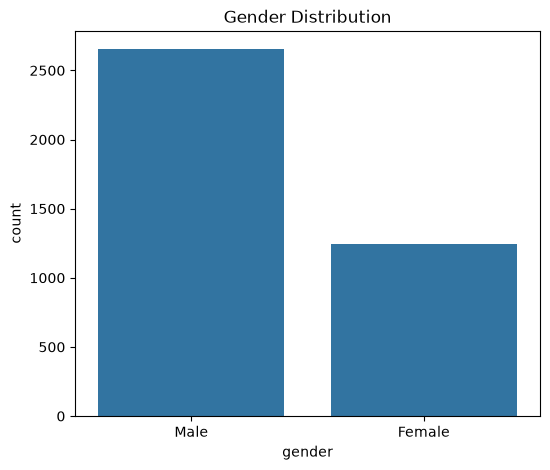

In [20]:
# Plot gender distribution
fig, ax = plt.subplots(figsize=(6, 5))
graph = sns.countplot(x='gender', data=df, ax=ax)
plt.title('Gender Distribution')

The dataset is  heavily skewed toward males with a 2:1 ratio, meaning the number of males is more than double that of females. If this variable is used for modeling, thn the class imbalance will have to be adressed to avoid model bias.

Text(0.5, 1.0, 'Distribution of Category')

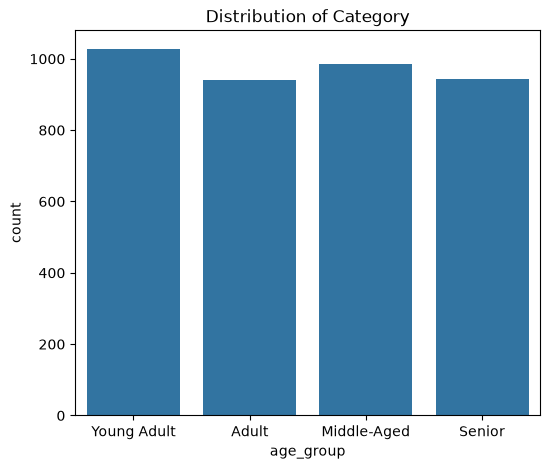

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
graph = sns.countplot(x='age_group', data=df, ax=ax)
plt.title('Distribution of Category')

The age group feature shows a highly balanced and uniform distribution, with the young_adult category peaking just above 1000. 

Text(0.5, 1.0, 'Distribution of Category')

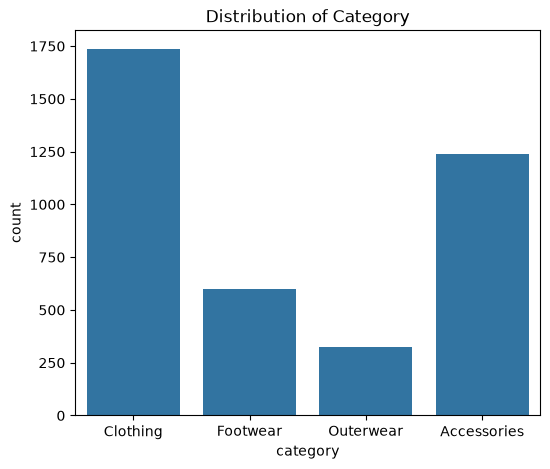

In [22]:
fig, ax = plt.subplots(figsize=(6, 5))
graph = sns.countplot(x='category', data=df, ax=ax)
plt.title('Distribution of Category')

The category that sells the most by far is the clothing category. 

Text(0, 0.5, 'Count')

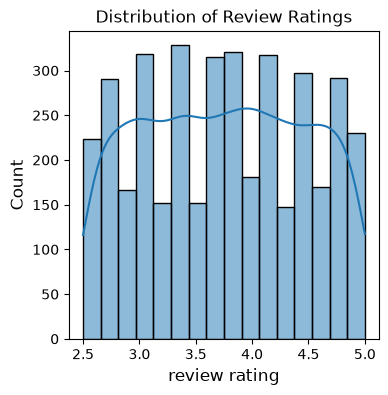

In [23]:
# Plot review rating distribution
fig, ax = plt.subplots(figsize=(4, 4))
graph = sns.histplot(x='review_rating', data=df, ax=ax,kde=True)  #use KDE=True to make the distribution easier to interpret
plt.title('Distribution of Review Ratings')
plt.xlabel('review rating', fontsize=12)
plt.ylabel('Count', fontsize=12)

The ratings range from 2.5 to 5, with observations spread fairly evenly. There are no obvious peaks or signs of strong skewness. This suggests that customer satisfaction varies among purchases, making ratings a potentially useful feature for identifying segments. The KDE shows a slight concentration of ratings around 3.8 to 4, indicating that moderately positive reviews are somewhat more common than the lower ones.

|       |   purchase_amount |
|:------|------------------:|
| count |         3900      |
| mean  |           59.7644 |
| std   |           23.6854 |
| min   |           20      |
| 25%   |           39      |
| 50%   |           60      |
| 75%   |           81      |
| max   |          100      |


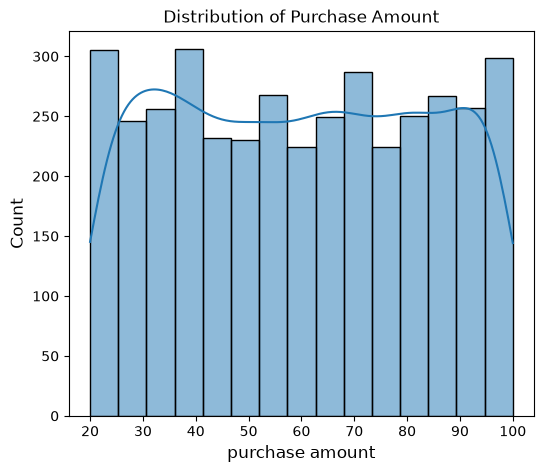

In [24]:
# Plot purchase amount distribution
fig, ax = plt.subplots(figsize=(6, 5))
graph = sns.histplot(x='purchase_amount', data=df, ax=ax, kde=True)
plt.title('Distribution of Purchase Amount')
plt.xlabel('purchase amount', fontsize=12)
plt.ylabel('Count', fontsize=12)

print(df['purchase_amount'].describe().to_markdown())

There is no strong concentration around any particular value. The KDE is relatively flat indicating that spending is not normally distributed but instead follows an approximately uniform (rectangular) distribution. Purchase amounts are strictly bounded between 20 and 100.

Text(0, 0.5, 'Count')

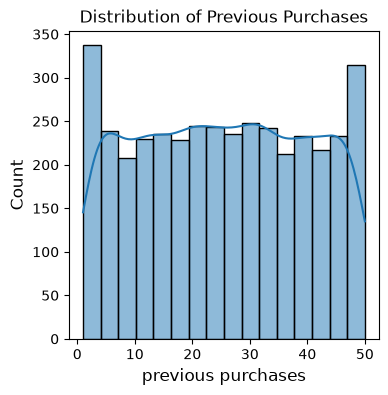

In [25]:
# Plot previous purchases distribution
fig, ax = plt.subplots(figsize=(4, 4))
graph = sns.histplot(x='previous_purchases', data=df, ax=ax,kde=True)
plt.title('Distribution of Previous Purchases')
plt.xlabel('previous purchases', fontsize=12)
plt.ylabel('Count', fontsize=12)

Text(0.5, 0, 'frequency of purchase')

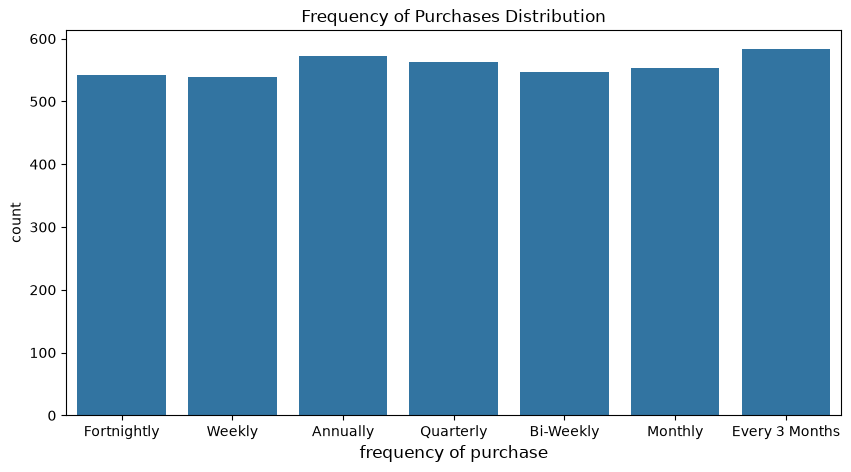

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
graph = sns.countplot(x='frequency_of_purchases', data=df, ax=ax)
plt.title('Frequency of Purchases Distribution')
plt.xlabel('frequency of purchase', fontsize=12)

The distribution is fairly even across all categories. 

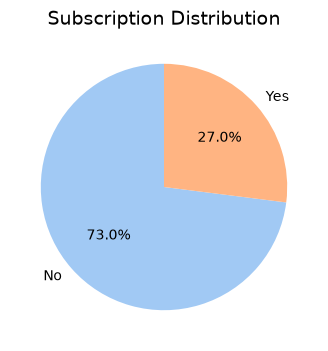

In [27]:
# Get counts
data_counts = df['subscription_status'].value_counts()

# Create the pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    data_counts, 
    labels=data_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sns.color_palette('pastel')
)

# Style and display
plt.title('Subscription Distribution', fontsize=14)
plt.show()

73% of the customers are subscribed, indicating a high customer adoption rate. 27% of customers are not subscribed, indicating a potential market for future subscription growth.

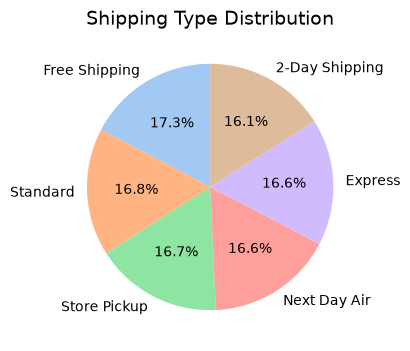

In [28]:
# Get counts
data_counts = df['shipping_type'].value_counts()

# Create the pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    data_counts, 
    labels=data_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sns.color_palette('pastel')
)

# Style and display
plt.title('Shipping Type Distribution', fontsize=14)
plt.show()

The data for the type of shipment is evenly distributed.

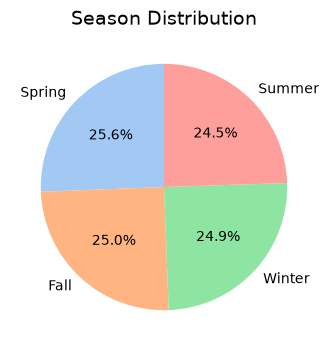

In [29]:
# Get counts
data_counts = df['season'].value_counts()

# Create the pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    data_counts, 
    labels=data_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sns.color_palette('pastel')
)

# Style and display
plt.title('Season Distribution', fontsize=14)
plt.show()

The data for the seasons is evenly distributed. No season stands out as having the highest purchases.

## 8.2 Bivariate Analysis

#### Clothing Category and Item Purchased.

Text(0, 0.5, 'count')

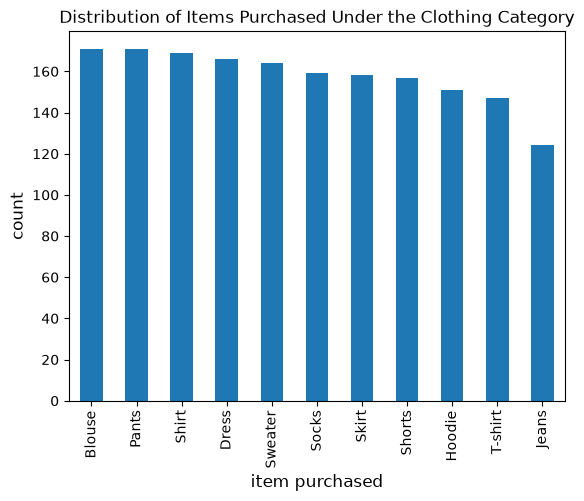

In [30]:
# Find the best-selling category by total sales
best_category = df.groupby('category')['purchase_amount'].sum().idxmax()

# Filter the dataframe for only that top category
top_category_df = df[df['category'] == best_category]

top_category_df["item_purchased"].value_counts().plot(kind="bar")
plt.title('Distribution of Items Purchased Under the Clothing Category')
plt.xlabel('item purchased', fontsize=12)
plt.ylabel('count', fontsize=12)

As indicated in the previous graph, clothing is the top-selling category, with blouses, pants, and shirts emerging as the three most popular items.

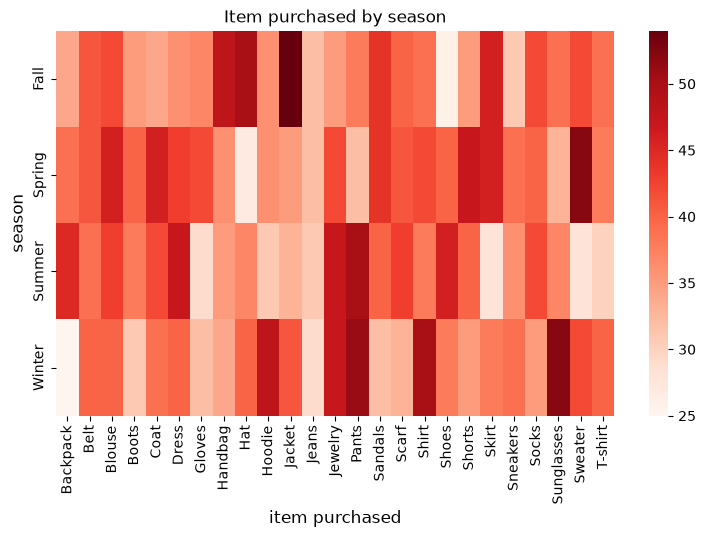

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
table = pd.crosstab(df['season'], df['item_purchased'])
sns.heatmap(table, annot=False, cmap='Reds', fmt='d')
plt.title('Item purchased by season')
plt.xlabel('item purchased', fontsize=12)
plt.ylabel('season', fontsize=12)
plt.show()

In winter, sunglasses and pants seem to sell more. Customers buy more hats and jackets in fall. Sweaters sell more in spring. And during summertime, dresses and jewelry sell the most.

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Female,1248.0,60.249199,23.420556,20.0,40.0,60.0,81.0,100.0
Male,2652.0,59.536199,23.809976,20.0,38.0,60.0,80.0,100.0


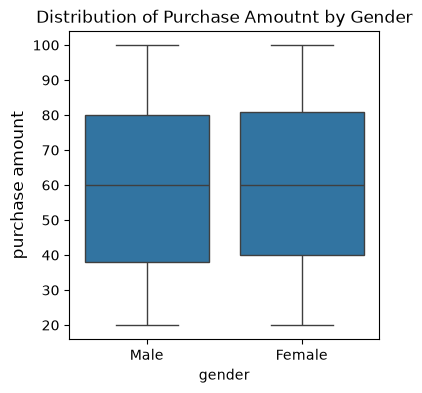

In [32]:
fig, ax = plt.subplots(figsize=(4, 4))
graph = sns.boxplot(x='gender', y='purchase_amount', data=df, ax=ax)
plt.title('Distribution of Purchase Amoutnt by Gender')
plt.ylabel('purchase amount', fontsize=12)

df.groupby('gender')['purchase_amount'].describe()

Although the data has more male customers than female customers, there are no major differences in median purchase amount between the two groups.

Text(0, 0.5, 'purchase amount')

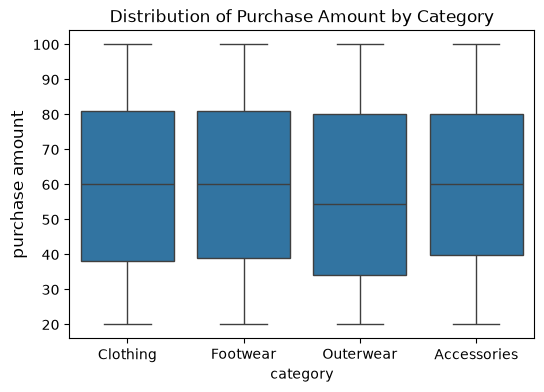

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))
graph = sns.boxplot(x='category', y='purchase_amount', data=df, ax=ax)
plt.title('Distribution of Purchase Amount by Category')
plt.ylabel('purchase amount', fontsize=12)

Clothing, footwear, and accessories have the same distribution when it comes to purchase amount. So customers usually spend around the same amount when they purchase items under these categories. Outwear has the lowest median purchase amount, indicating that customers generally spend less on outwear purchases

Text(0, 0.5, 'purchase amount')

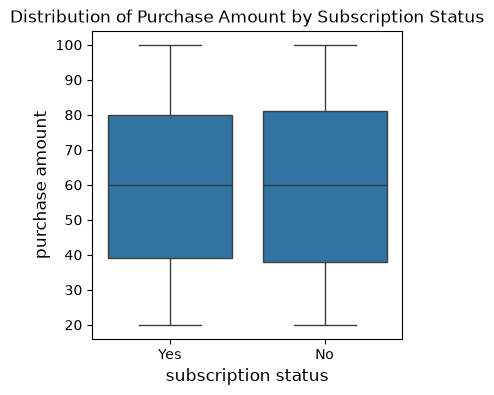

In [34]:
fig, ax = plt.subplots(figsize=(4, 4))
graph = sns.boxplot(x='subscription_status', y='purchase_amount', data=df, ax=ax)
plt.title('Distribution of Purchase Amount by Subscription Status')
plt.xlabel('subscription status', fontsize=12)
plt.ylabel('purchase amount', fontsize=12)

Customers generally spend the same amount regardless of whether they are subscribed or not.

Text(0, 0.5, 'purchase amount')

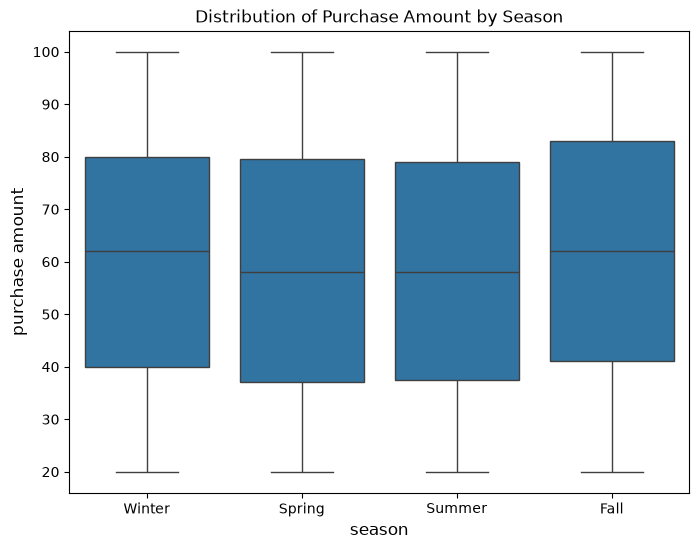

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
graph = sns.boxplot(x='season', y='purchase_amount', data=df, ax=ax)
plt.title('Distribution of Purchase Amount by Season')
plt.xlabel('season', fontsize=12)
plt.ylabel('purchase amount', fontsize=12)

Seasonal spending patterns show that customers spend more in winter and fall, whereas spending decreases during the warmer months.

Text(0, 0.5, 'purchase amount')

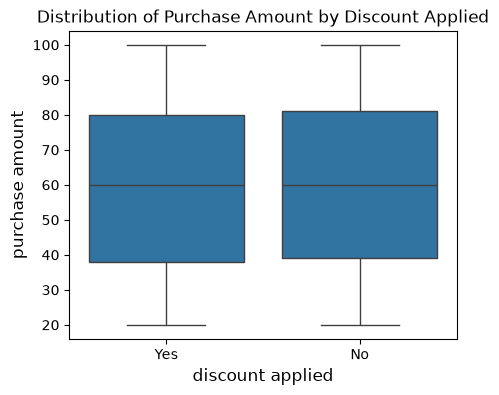

In [36]:
fig, ax = plt.subplots(figsize=(5, 4))
graph = sns.boxplot(x='discount_applied', y='purchase_amount', data=df, ax=ax)
plt.title('Distribution of Purchase Amount by Discount Applied')
plt.xlabel('discount applied', fontsize=12)
plt.ylabel('purchase amount', fontsize=12)

Discounts do not encourage bigger purchases.

## 8.3 Multivariate Analysis

Text(42.139269755045575, 0.5, 'purchase amount')

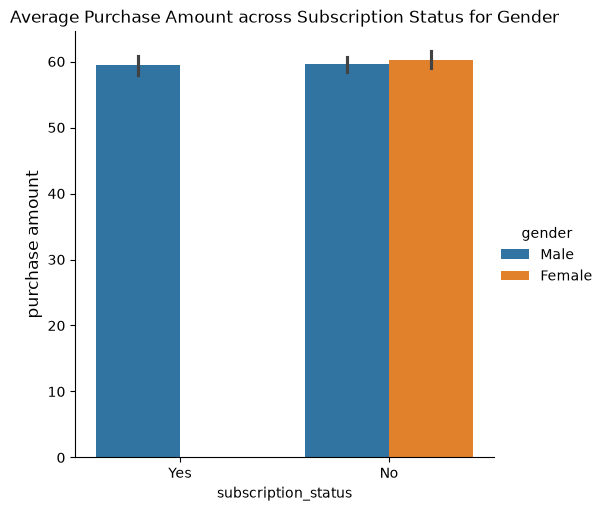

In [37]:
graph = sns.catplot(x='subscription_status', y='purchase_amount', hue='gender', data=df,kind='bar')
plt.title('Average Purchase Amount across Subscription Status for Gender')
plt.ylabel('purchase amount', fontsize=12)

In [38]:
print(pd.crosstab(df['subscription_status'],df['gender']))
print(pd.crosstab(df['discount_applied'],df['gender']))

gender               Female  Male
subscription_status              
No                     1248  1599
Yes                       0  1053
gender            Female  Male
discount_applied              
No                  1248   975
Yes                    0  1677


The above plot reveals that all subsciribed customers are male, while no female customers had an active subscription. This is an unusual pattern for real-world retail data and suggests that the data may be synthetic or designed for educational purposes. Therefore, findings related to subscription status should be interpreted with caution, as they may not reflect realistic customer behavior. The same could be said about discount_applied. Subscription_status and discount_applied will be excluded when modeling to avoid overlapping infromation with gender.

Text(42.139269755045575, 0.5, 'purchase amount')

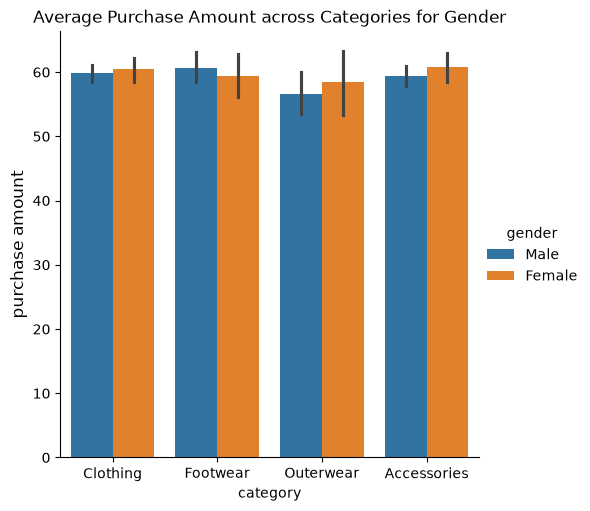

In [39]:
graph = sns.catplot(x='category', y='purchase_amount', hue='gender', data=df,kind='bar')
plt.title('Average Purchase Amount across Categories for Gender')
plt.ylabel('purchase amount', fontsize=12)

Spending patterns are generally similar between genders across all categories. Female customers tend to spend slightly more on clothing, outwear, and accessories, while males spend more on footwear. The overall differences are small, suggesting that gender might have limited influence on average spending within each category.

Text(46.70424839952257, 0.5, 'purchase amount')

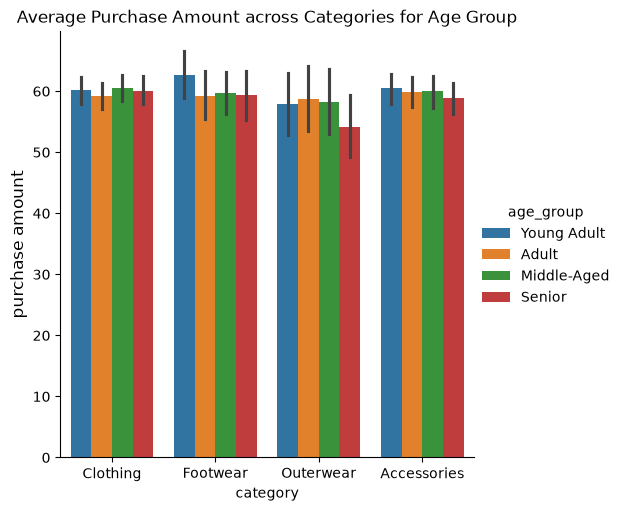

In [40]:
graph = sns.catplot(x='category', y='purchase_amount', hue='age_group', data=df,kind='bar')
plt.title('Average Purchase Amount across Categories for Age Group')
plt.ylabel('purchase amount', fontsize=12)

All age groups spend similar amounts on clothing. Young adults have the highest average purchase amount for footwear. Outerwear has the lowest average purchase amount across all age groups. Senior customers spend noticeably less on outerwear than the other age groups. Young adults and middle-aged customers spend marginally more than adults and seniors.

## 8.4 Correlation Analysis

In [41]:
objList = df.select_dtypes(include = "str").columns            #finding features with type str
objList

Index(['gender', 'item_purchased', 'category', 'location', 'size', 'color',
       'season', 'subscription_status', 'shipping_type', 'discount_applied',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [42]:
to_encode = df.drop(['customer_id','size','location','color',
               'item_purchased','frequency_of_purchases',
              'age_group'], axis = 1)
to_encode['gender'] = le.fit_transform(to_encode['gender'])
to_encode['subscription_status'] = le.fit_transform(to_encode['subscription_status'])
to_encode['discount_applied'] = le.fit_transform(to_encode['discount_applied'])

df_encoded = pd.get_dummies(to_encode,drop_first = True)
df_encoded.head()

,age,gender,purchase_amount,review_rating,subscription_status,discount_applied,previous_purchases,category_Clothing,category_Footwear,category_Outerwear,...,shipping_type_Express,shipping_type_Free Shipping,shipping_type_Next Day Air,shipping_type_Standard,shipping_type_Store Pickup,payment_method_Cash,payment_method_Credit Card,payment_method_Debit Card,payment_method_PayPal,payment_method_Venmo
0,55,1,53,3.1,1,1,14,True,False,False,...,True,False,False,False,False,False,False,False,False,True
1,19,1,64,3.1,1,1,2,True,False,False,...,True,False,False,False,False,True,False,False,False,False
2,50,1,73,3.1,1,1,23,True,False,False,...,False,True,False,False,False,False,True,False,False,False
3,21,1,90,3.5,1,1,49,False,True,False,...,False,False,True,False,False,False,False,False,True,False
4,45,1,49,2.7,1,1,31,True,False,False,...,False,True,False,False,False,False,False,False,True,False


<Axes: >

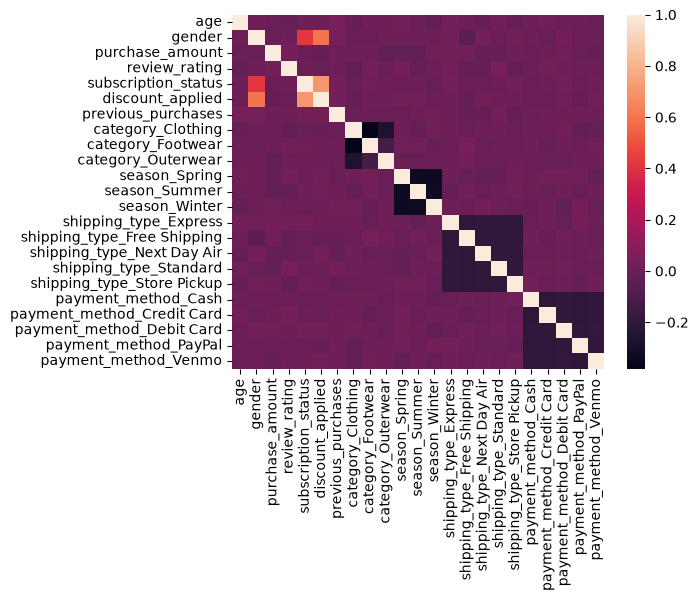

In [43]:
#Using Pearson Correlation
plt.figure(figsize=(6,4.6))
cor = df_encoded.corr()
sns.heatmap(cor)

This correlation heatmap shows the relationships between the encoded variables in the dataset. Most variables show a weak correlation with values close to zero. This indicates that the features are largely independent and there is no serious multicollinearity, which is desirable for modeling. Customers with subscriptions appear more likely to receive or use discounts, but both these features have a strong correlation with gender and each other. Hence adding to the point that they will be excluded in the modeling process. Customer demographics and purchasing behavior do not exhibit strong linear relationships with the encoded categorical variables.

## 8.5 Outlier Detection

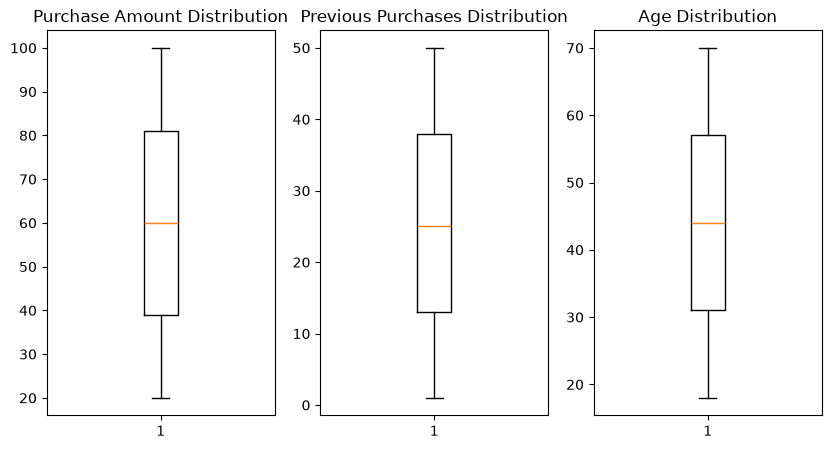

In [44]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(10, 5), sharey=False)

# Plot on the first axis
ax1.boxplot(df['purchase_amount'])
ax1.set_title('Purchase Amount Distribution')

# Plot on the second axis
ax2.boxplot(df['previous_purchases'])
ax2.set_title('Previous Purchases Distribution')

# Plot on the third axis
ax3.boxplot(df['age'])
ax3.set_title('Age Distribution')

plt.show()

Purchase_amount, previous_purchases, and age  do not have outliers.

## 8.6 Summary of EDA

The exploratory analysis revealed that customer spending varies across product categories and subscription status. Customers exhibit different purchase frequencies and previous purchase histories, suggesting potential behavioral differences suitable for clustering. Although review ratings show limited variation, purchase amount and purchase frequency provide strong indicators of customer engagement. These findings support the use of clustering techniques to identify distinct customer segments for targeted marketing strategies.

<a id="pp"></a>
# 9. Feature Engineering

Feature engineering is the process of selecting and transforming variables into an idealformat before using them in predictive model. The features in the data will directly influence the predictive models we use and the results we obtain

Features that are **eligible** to be used for modeling

**Ready for use:**
 * Age  - Important demographic feature.
 * Purchase Amount - Strong segmentation variable.
 * Previous Purchases - Excellent measure of customer loyalty.
 * Review Rating - Represents customer satisfaction.
 

**Encode:**
 * Gender - Can help distinguish customer groups.
 * Category - Reflects product preference.
 * Season - Captures seasonal buying patterns.
 * Frequency of Purchases - Informative behavioral feature.

## 9.1  Adding Features

#### Create purchase_frequency_days column 

In [45]:
frquency_mapping = {
    'Fortnightly' : 14,
    'Weekly' : 7,
    'Monthly' : 30,
    'Quarterly' : 90,
    'Annually' : 365,
    'Every 3 Months': 90,
    'Bi-Weekly' : 14,
}

# Add to dfbecause it will be usefull after modeling
df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frquency_mapping)
df[['purchase_frequency_days','frequency_of_purchases']].head(8)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly


#### Create high_spender column 

In [46]:
df_add = df.copy()

In [47]:
median_purchase = df_add['purchase_amount'].median()

df_add['high_spender'] = (
    df_add['purchase_amount'] > median_purchase
).astype(int)

Customers who spend more than the average purchase amount are classified as high spenders.

## 9.2  Encoding

#### Encode gender

In [48]:
df_binary = df_add.copy()

In [49]:
df_binary['gender'] = le.fit_transform(df_binary['gender'])

#### One-Hot Encoding

In [50]:
df_drop = df_binary.drop(['customer_id','size','discount_applied',
               'location','color','item_purchased','age_group',
               'shipping_type','payment_method','season',
                "frequency_of_purchases",'subscription_status'
               ], axis = 1) 
df_enc = pd.get_dummies(df_drop,drop_first = True)

df_enc.head()

,age,gender,purchase_amount,review_rating,previous_purchases,purchase_frequency_days,high_spender,category_Clothing,category_Footwear,category_Outerwear
0,55,1,53,3.1,14,14,0,True,False,False
1,19,1,64,3.1,2,14,1,True,False,False
2,50,1,73,3.1,23,7,1,True,False,False
3,21,1,90,3.5,49,7,1,False,True,False
4,45,1,49,2.7,31,365,0,True,False,False


#### Correlation Check

I used a heatmap to rule out any features that are highly correlated

<Axes: >

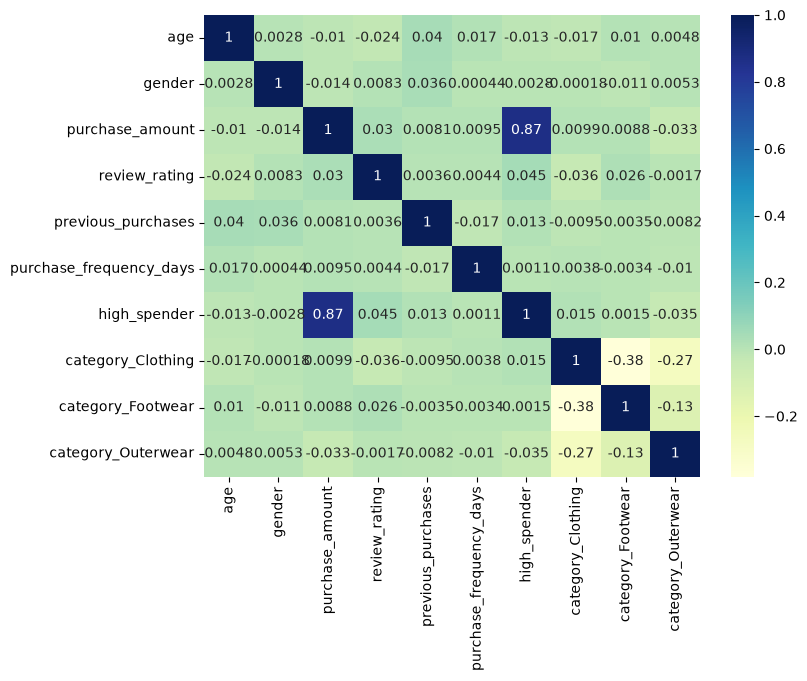

In [51]:
# Using Pearson Correlation
plt.figure(figsize=(8,6))
cor = df_enc.corr()
sns.heatmap(cor, cmap="YlGnBu", annot=True)

No two variables correlate above about 0.85, so all features can be used in the modeling process.

## 9.3 Scaling
Scaling prevents large-scale features from dominating smaller ones, helps models train faster, and improves overall prediction accuracy. 
To scale the data we will use z-score scaling.

**Z-score Standardization:** The values in the feature column are standardized by removing the mean and scaling the variance to be 1 from the values. This method is known as Scaling or Centering.

                                                 

$$z =  \frac{x - \mu}{\sigma}$$


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_features = ['age', 
                      'purchase_amount',
                      'review_rating',
                      'previous_purchases',
                      'purchase_frequency_days',
                     ]

X = df_enc.copy()
X[numerical_features] = scaler.fit_transform(X[numerical_features])
X[numerical_features].head()

,age,purchase_amount,review_rating,previous_purchases,purchase_frequency_days
0,0.718913,-0.285629,-0.911076,-0.785831,-0.631252
1,-1.648629,0.178852,-0.911076,-1.616552,-0.631252
2,0.390088,0.558882,-0.911076,-0.162789,-0.690065
3,-1.517099,1.276716,-0.350458,1.637107,-0.690065
4,0.061263,-0.454531,-1.471695,0.391025,2.317775


In [54]:
X.head()

,age,gender,purchase_amount,review_rating,previous_purchases,purchase_frequency_days,high_spender,category_Clothing,category_Footwear,category_Outerwear
0,0.718913,1,-0.285629,-0.911076,-0.785831,-0.631252,0,True,False,False
1,-1.648629,1,0.178852,-0.911076,-1.616552,-0.631252,1,True,False,False
2,0.390088,1,0.558882,-0.911076,-0.162789,-0.690065,1,True,False,False
3,-1.517099,1,1.276716,-0.350458,1.637107,-0.690065,1,False,True,False
4,0.061263,1,-0.454531,-1.471695,0.391025,2.317775,0,True,False,False


<a id="kk"></a>
# 10. Determine Optimal Number of Clusters

Determining the optimal value for k by using a dendrogram for Agglomerative Hierarchical Clustering, AIC/BIC for Gaussian Mixture Model, and the Elbow Method for K-Means Clustering.

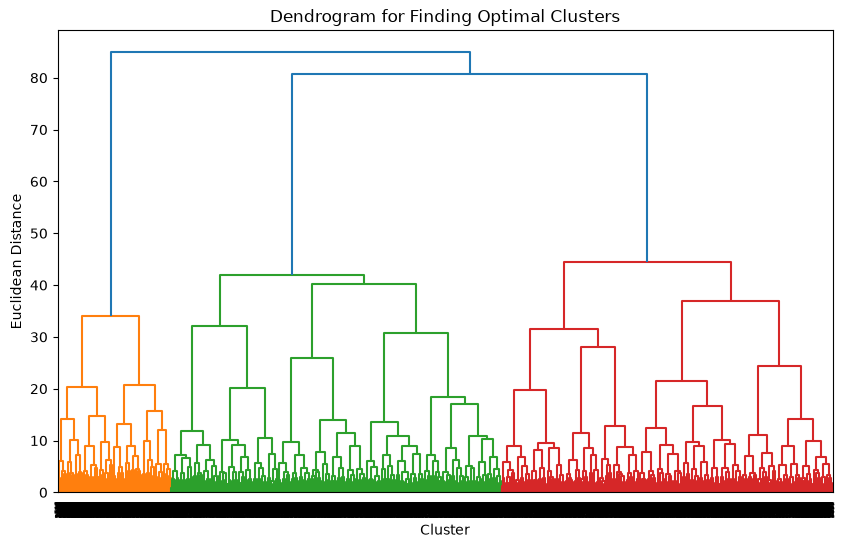

In [55]:
import scipy.cluster.hierarchy as sch

pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X)

#  Plot the dendrogram
plt.figure(figsize=(10, 6))
# 'ward' linkage minimizes variance during merges
linkage_matrix = sch.linkage(X_pca, method='ward') 
dendrogram = sch.dendrogram(linkage_matrix)

plt.title('Dendrogram for Finding Optimal Clusters')
plt.xlabel('Cluster')
plt.ylabel('Euclidean Distance')
plt.show()

The dendrogram reveals three distinctly colored primary branches (orange, green, and red), indicating a clear separation of the data. Thus a three-cluster solution was determined to be optimal for this dataset. This choice effectively balances cluster homogeneity with model simplicity.

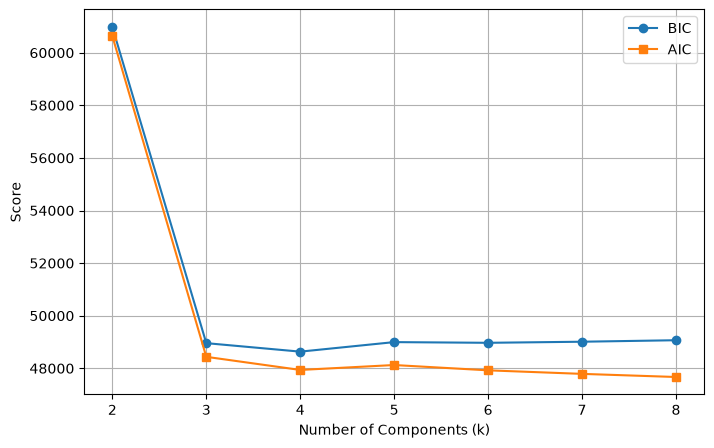

In [56]:
n_components = range(2,9)

bic_scores = []
aic_scores = []

for k in n_components:
    gmm = GaussianMixture(n_components=k,
                          random_state=42,
                          covariance_type='full')

    gmm.fit(X_pca)

    bic_scores.append(gmm.bic(X_pca))
    aic_scores.append(gmm.aic(X_pca))

# Plot
plt.figure(figsize=(8,5))
plt.plot(n_components,bic_scores, marker='o', label='BIC')
plt.plot(n_components,aic_scores, marker='s', label='AIC')

plt.xlabel('Number of Components (k)')
plt.ylabel('Score')
plt.xticks(n_components)
plt.legend()
plt.grid(True)

plt.show()

This plot evaluates a Gaussian Mixture Model (GMM) using Bayesian Information Criterion (BIC) and Akaike Information Criterion (AIC) to determine the optimal number of clusters. There is a massive drop in both BIC and AIC scores when moving from 2 to 3 components. This indicates that moving to at least 3 components vastly improves model fit. When AIC and BIC point to different numbers, BIC is generally preferred for cluster selection because it is asymptotically consistent and prevents over-clustering. Since BIC clearly minimizes at k = 4 and AIC shows a major elbow/inflection point there, k = 4 is the optimal number of components.

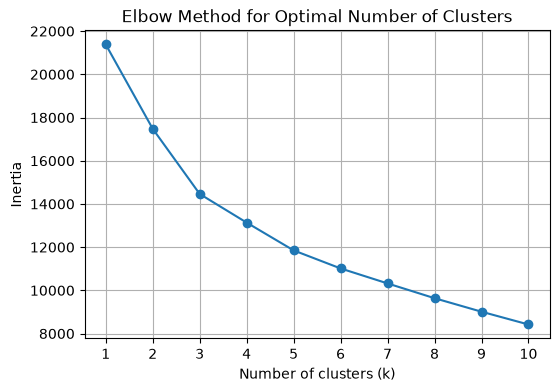

In [57]:
# List to store inertia values
inertia = []

# Test diffferent numbers of clusters
K = range(1,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit_predict(X_pca)
    inertia.append(kmeans.inertia_)


# Plot the Elbow Curve
plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K)
plt.grid(True)

plt.show()

To identify the optimal number of clusters for the K-Means algorithm, the Elbow Method was employed. The resulting curve shows a steep, rapid drop from k=1 to k=3. A distinct inflection point—or "elbow"—is observed at k=3 (extending marginally to k=4, after which the rate of decline flattens significantly and follows a gradual, linear trajectory). A three-cluster or four-cluster segmentation would be optimal. 

<a id="mm"></a>
# 11. Modeling

**Customer Segmentation** Customer segmentation is the process of examining customer attributes and creating groups based on how they behave, who they are, and their specific characteristics. Customer segmentation allows businesses to use targeted messaging, rather than taking a one-size-fits-all approach, to drive business results. In this project I will use demographic and behavioral segmentation to help the company gain insights that can help them determine the most effective way to spend their marketing budget. Agglomerative Hierarchical Clustering, Gaussian Mixture, and K-Means models will be used to segment the customers.

1. **Agglomerative Hierarchical Clustering** - Hierarchical Clustering is an unsupervised learning technique that groups data into a hierarchy of clusters based on similarity. It builds a tree-like structure called a dendrogram, which helps visualise relationships and decide the optimal number of clusters.

At each step, the two closest clusters are merged.

$$
C_i,\; C_j \rightarrow C_{ij}
$$

The distance between clusters depends on the chosen linkage criterion.

##### Ward's Linkage

Ward's method merges the pair of clusters that results in the smallest increase in within-cluster variance.

$$
\Delta(C_i,C_j)
=
\frac{|C_i||C_j|}
{|C_i|+|C_j|}
\left\|
\mu_i-\mu_j
\right\|^2
$$

   * Agglomerative Hierarchical Clustering does not require pre-selecting the number of clusters
   * Uses agglomerative (bottom up) or divisive (top down) approaches

2. **Gaussian Mixture Model (GMM)** -  Gaussian Mixture Model is a probabilistic clustering technique that models data as a combination of multiple Gaussian distributions, allowing more flexible grouping of data points. The Gaussian Mixture Model (GMM) clustering equation defines the total probability density function of a data point as a weighted sum of multi-variable normal distributions: 

$$
p(x)=\sum_{k=1}^{K}\pi_k\,\mathcal{N}(x\mid\mu_k,\Sigma_k)
$$

where:

- $K$ = number of Gaussian components
- $\pi_k$ = mixing coefficient (weight) of the \(k^{th}\) Gaussian
- $\mu_k$ = mean vector
- $\Sigma_k$ = covariance matrix
- $\mathcal{N}(x\mid\mu_k,\Sigma_k)$ = Gaussian probability density function
      
4. **K-Means** - K-means is an unsupervised learning method for clustering data points. The algorithm iteratively divides data points into K clusters by minimizing the variance in each cluster. Each data point x is assigned to the nearest centroid, forming k clusters, where the "nearest" centroid is determined by the minimum distance between the point and all centroids.
Here, the distance d between a point x and a centroid μi is typically calculated using the Euclidean distance:

$$
d = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}
$$
where xj​ and μij​ are the j-th dimensions of point x and centroid μi, respectively.

* Requires us define K upfront
* Helps identify natural groupings in unlabeled datasets
* Works by grouping points based on distance to cluster centers

### Fit Models

#### Agglomerative Clustering

In [58]:
results_agg = []

for variance in [0.90, 0.95]:
    print(variance)  # keep track of progress
    
    pca = PCA(n_components=variance)
    X_pca = pca.fit_transform(X)

    for k in range(2,9):

        for linkage in ['average','complete','ward']:

           # if linkage == 'ward':
            model = AgglomerativeClustering(
                    n_clusters=k,
                    linkage=linkage,
                    metric='euclidean'
                )
           # else:
                #model = AgglomerativeClustering(
                #    n_clusters=k,
                #    linkage=linkage,
               #     metric='euclidean'
               # )

            labels = model.fit_predict(X_pca)

            silhouette = silhouette_score(X_pca, labels)
            ch = calinski_harabasz_score(X_pca, labels)
            db = davies_bouldin_score(X_pca, labels)

            results_agg.append({
                'Variance': variance,
                'Model':'Agglomerative',
                'k':k,
                'Linkage':linkage,
                'Silhouette':silhouette,
                'CH':ch,
                'DB':db
            })

results_agg_df = pd.DataFrame(results_agg)

0.9
0.95


#### K-Means

In [59]:
kmeans_params = {
    'n_clusters': [2,3,4,5,6,7,8],
    'init': ['k-means++', 'random'],
    'n_init': [10,20,50],
    'max_iter': [300,500]
}

In [60]:
from itertools import product

results_km = []
for variance in [0.90, 0.95]:
    print(variance)  # keep track of progress
    
    pca = PCA(n_components=variance)
    X_pca = pca.fit_transform(X)

    for k, init, n_init, max_iter in product(

        kmeans_params['n_clusters'],
        kmeans_params['init'],
        kmeans_params['n_init'],
        kmeans_params['max_iter']):

        model = KMeans(n_clusters=k,
                       init=init,
                       n_init=n_init,
                       max_iter=max_iter,
                       random_state=42)
                           

        labels = model.fit_predict(X_pca)

        results_km.append({
            'Variance': variance,
            'Model':'K-Means',
            'k': k,
            'init': init,
            'n_init': n_init,
            'max_iter': max_iter,
            'Silhouette': silhouette_score(X_pca, labels),
            'CH': calinski_harabasz_score(X_pca, labels),
            'DB': davies_bouldin_score(X_pca, labels)
    })

results_km_df = pd.DataFrame(results_km)

0.9
0.95


#### Gaussian Mixture

In [61]:
gmm_params = {
    'n_components':[2,3,4,5,6,7,8],
    'covariance_type':['full','diag','tied','spherical'],
    'init_params':['kmeans','random'],
    'reg_covar':[1e-6,1e-5,1e-4]
}

In [ ]:
from itertools import product

results_gmm = []
for variance in [0.90, 0.95]:
    print(variance)  # keep track of progress
    
    pca = PCA(n_components=variance)
    X_pca = pca.fit_transform(X)

    for k, covariance_type, init_params, reg_covar in product(
            
        gmm_params['n_components'],
        gmm_params['covariance_type'],
        gmm_params['init_params'],
        gmm_params['reg_covar']):

        
        model = GaussianMixture(n_components=k,
                       covariance_type=covariance_type,
                       init_params=init_params,
                       reg_covar=reg_covar,
                       random_state=42)

        labels = model.fit_predict(X_pca)

        results_gmm.append({
            'Variance': variance,
            'Model':'Gaussian',
            'k': k,
            'covariance_type': covariance_type,
            'init_params': init_params,
            'reg_covar': reg_covar,
            'Silhouette': silhouette_score(X_pca, labels),
            'CH': calinski_harabasz_score(X_pca, labels),
            'DB': davies_bouldin_score(X_pca, labels)
    })

results_gmm_df = pd.DataFrame(results_gmm)

0.9
0.95


#### Summary Table

In [ ]:
models_result = pd.concat([results_agg_df, results_km_df,results_gmm_df], axis=0, ignore_index=True)

models_result

<a id="me"></a>
# 12. Modeling Evaluation

Run the best performing models through a range of k values to better visualize and pick the best model out of the three.

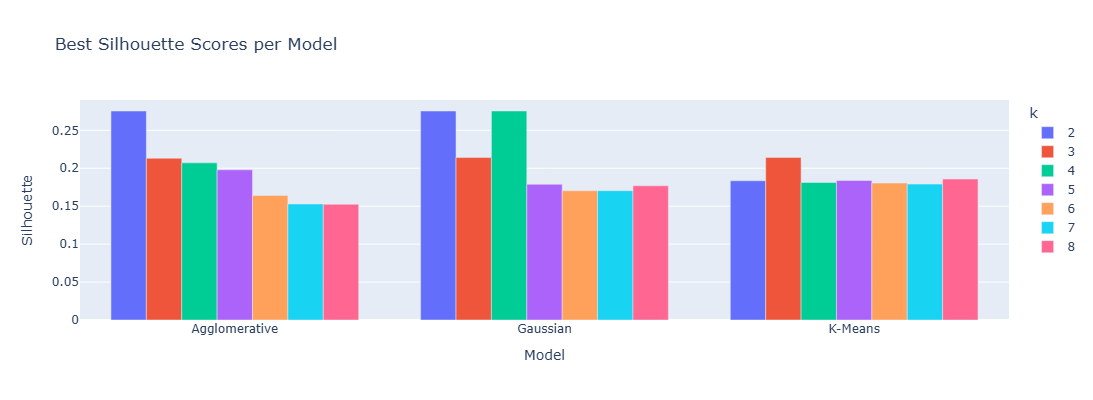

In [65]:
best_silhouette = (models_result.sort_values('Silhouette', ascending=False)
                   .drop_duplicates(subset=['Model', 'k'])
                   .sort_values(['Model', 'k'])
                  )
best_silhouette['k'] = best_silhouette['k'].astype(str)
fig = px.bar(best_silhouette, x="Model", y="Silhouette", 
             color='k',
             barmode='group', height=400,
            title='Best Silhouette Scores per Model')
fig.show()

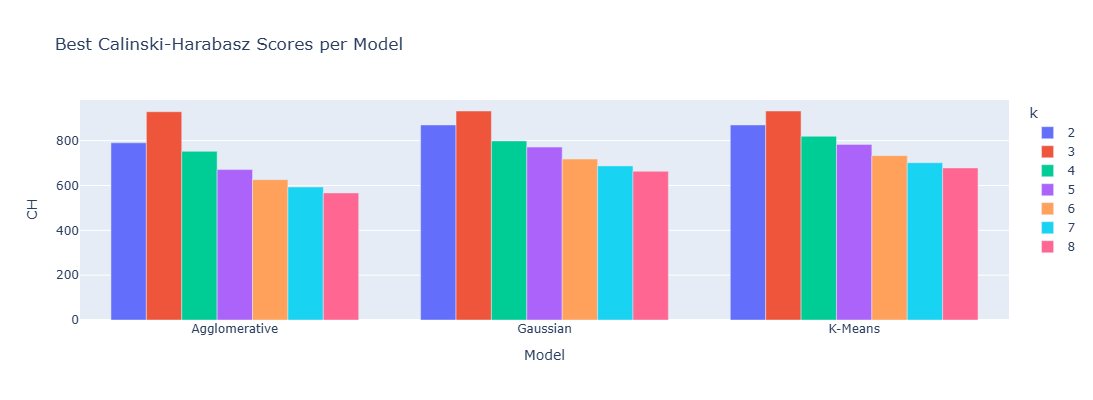

In [66]:
best_ch = (models_result.sort_values('CH', ascending=False)
                   .drop_duplicates(subset=['Model', 'k'])
                   .sort_values(['Model', 'k'])
                  )
best_ch['k'] = best_ch['k'].astype(str)
fig = px.bar(best_ch, x="Model", y="CH", 
             color='k',
             barmode='group', height=400,
            title='Best Calinski-Harabasz Scores per Model')
fig.show()

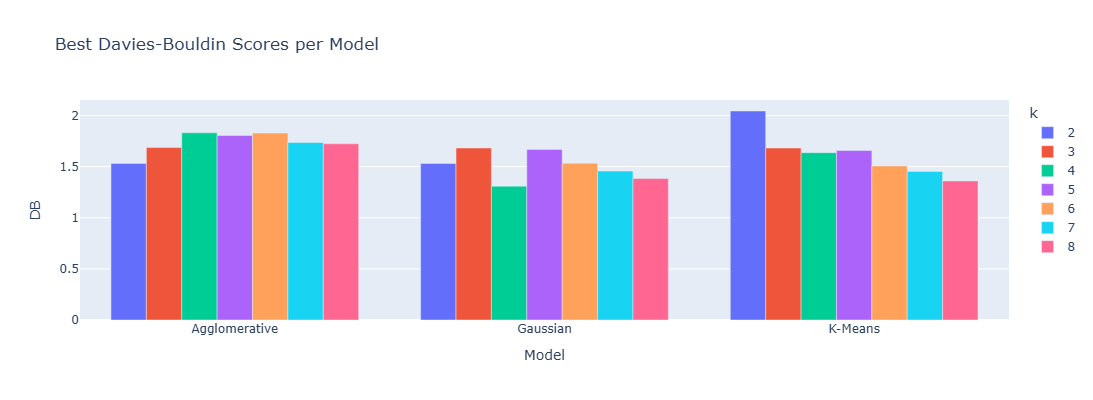

In [67]:
best_ch = (models_result.sort_values('DB', ascending=True)
                   .drop_duplicates(subset=['Model', 'k'])
                   .sort_values(['Model', 'k'])
                  )
best_ch['k'] = best_ch['k'].astype(str)
fig = px.bar(best_ch, x="Model", y="DB", 
             color='k',
             barmode='group', height=400,
            title='Best Davies-Bouldin Scores per Model')
fig.show()

Three clustering algorithms, K-Means, Agglomerative Clustering, and Gaussian Mixture Models (GMM), were evaluated using the Silhouette Score, Calinski-Harabasz Index, and Davies-Bouldin Index.
Although both Agglomerative Clustering and Gaussian Mixture Models performed well across the indices, K-Means consistently produced the lowest Davies-Bouldin Index, and it demonstrated the most balanced overall performance, indicating more compact and well-separated clusters. The performance differences between the algorithms were relatively small, suggesting that all three produced meaningful cluster structures. 

Considering its competitive performance across the evaluation metrics, computational efficiency, ease of interpretation and profiling, and widespread use in customer segmentation, K-Means was selected as the final clustering algorithm, with k=3 as supported by the Elbow MEthod.


In [68]:
# View parameters of kmeans model to be used to segment the customers with k=3
best_silhouette[(np.isclose(best_silhouette['Silhouette'], 0.214087)) 
    & (best_silhouette['k'] == '3') & (best_silhouette['Model'] == 'K-Means')]

,Variance,Model,k,Linkage,Silhouette,CH,DB,init,n_init,max_iter,covariance_type,init_params,reg_covar
65,0.9,K-Means,3,NaN,0.214087,932.184255,1.681664,random,50.0,500.0,NaN,NaN,NaN


In [69]:
# Best Model
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X)

kmeans =  KMeans(n_clusters=3,init='k-means++',random_state=42,max_iter=500,n_init=50)
cluster_df = df.copy()
cluster_df['cluster'] = kmeans.fit_predict(X_pca)
cluster_df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days,cluster
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-Aged,14,1
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14,0
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-Aged,7,0
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7,0
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-Aged,365,2


<a id="cp"></a>
# 13. Cluster Profiling

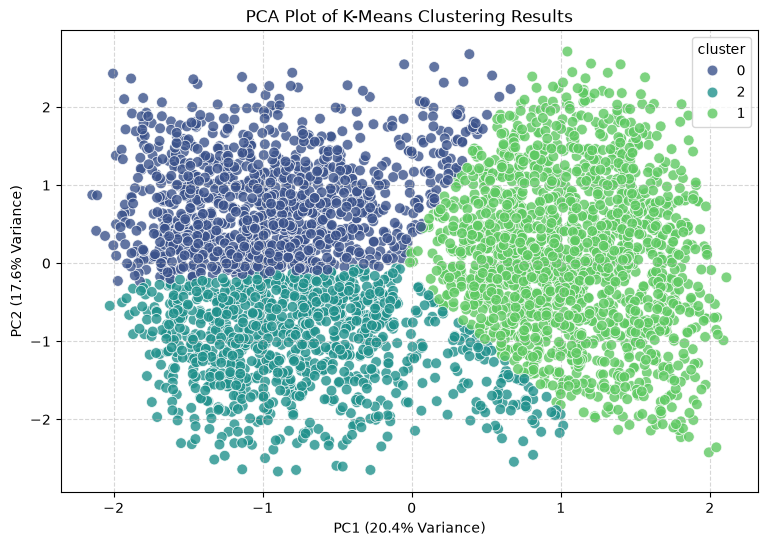

In [70]:
# Reduce the data to two principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

cluster_model =  KMeans(n_clusters=3,init='random',random_state=42,max_iter=300,n_init=50)
labels = cluster_model.fit_predict(X_pca)


df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cluster"] = labels.astype(str)


plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="viridis",
    alpha=0.8,
    edgecolor="w",
    s=60,
)

# Calculate variance explained for axes labels
var_exp = pca.explained_variance_ratio_ * 100
plt.xlabel(f"PC1 ({var_exp[0]:.1f}% Variance)")
plt.ylabel(f"PC2 ({var_exp[1]:.1f}% Variance)")
plt.title("PCA Plot of K-Means Clustering Results")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Principal Component Analysis (PCA) was used to reduce the multidimensional feature space to two principal components for visualization. The plot shows that the clusters are reasonably well separated, indicating that the K-Means algorithm successfully identified distinct customer segments. While some overlap exists between neighbouring clusters, the overall separation supports the clustering results obtained from the Silhouette Score, Calinski–Harabasz Index, and Davies–Bouldin Index.

### Profile Each Cluster

In [71]:
cluster_summary = cluster_df.groupby('cluster')[['age', 'purchase_amount',
                                         'review_rating','previous_purchases',
                                        'purchase_frequency_days']].mean() 
cluster_revenue = cluster_df.groupby('cluster')[['purchase_amount']].sum()
cluster_revenue.columns = ['total_revenue']
cluster_count = cluster_df.groupby('cluster').size().to_frame('count')#value_counts().sort_index())
df_profile = pd.concat([cluster_count,cluster_summary, cluster_revenue], axis=1).reset_index()

df_profile

,cluster,count,age,purchase_amount,review_rating,previous_purchases,purchase_frequency_days,total_revenue
0,0,1635,43.907645,80.607951,3.773333,25.720489,42.221407,131794
1,1,1693,44.021855,39.496751,3.725103,25.262256,41.232723,66868
2,2,572,44.666084,60.173077,3.757343,24.561189,365.000000,34419


**Cluster 0 - High-Value Loyal Customers**
This cluster represents the business's most valuable customers. They made the highest number of previous purchases, indicating strong customer loyalty and a high likelihood of repeat business. They also spend relatively large amounts per purchase while providing the highest review ratings, suggesting a high level of satisfaction with the products they purchase. Additionally, they purchase more than the other clusters. This segment is essential for maintaining revenue and

**Cluster 1 - Budget-Conscious Regular Customers**
Cluster 1 consists of customers who spend the least amount per transaction despite having a relatively high number of previous purchases. Their review ratings indicate a generally positive experience, providing an opportunity to strengthen the relationship with this segment. They appear to be price-sensitive and may respond well to discounts, coupons, bundled offers, or promotional campaigns aimed at increasing purchase value and improving customer satisfaction. They are also a good target for upselling.

**Cluster 2 - Occasional Customers**
This cluster includes customers who spend relatively high amounts when they make a purchase but have made relatively few purchases overall. They have the lowest overall revenue because of the small size and infrequent purchases. Their review ratings indicate a generally positive experience, providing an opportunity to strengthen the relationship with this segment. These customers have the potential to become loyal, high-value customers if encouraged through personalized recommendations, targeted promotions, and retention campaigns.


In [72]:
overall_mean = cluster_df.drop(columns=['cluster','customer_id']).mean(numeric_only=True)

comparison = cluster_summary - overall_mean

comparison.round(2)

,age,purchase_amount,review_rating,previous_purchases,purchase_frequency_days
cluster,,,,,
0,-0.16,20.84,0.02,0.37,-46.91
1,-0.05,-20.27,-0.02,-0.09,-47.90
2,0.60,0.41,0.01,-0.79,275.87


Positive values indicate the cluster is above average, while negative values indicate it is below average.

In [73]:
# Define the mapping for clusters
cluster_map = {
    0: 'High-Value Loyal',
    1: 'Budget-Conscious Regular',
    2: 'Occasional',
}

# Apply the mapping
cluster_df['cluster'] = cluster_df['cluster'].map(cluster_map)

--- Percentage Distribution of Frequency of Purchases per Cluster ---
frequency_of_purchases    Annually  Bi-Weekly  Every 3 Months  Fortnightly  \
cluster                                                                      
Budget-Conscious Regular       0.0       15.2            17.4         16.7   
High-Value Loyal               0.0       17.7            17.7         15.8   
Occasional                   100.0        0.0             0.0          0.0   

frequency_of_purchases    Monthly  Quarterly  Weekly  
cluster                                               
Budget-Conscious Regular     17.2       16.4    17.1  
High-Value Loyal             16.0       17.5    15.3  
Occasional                    0.0        0.0     0.0  


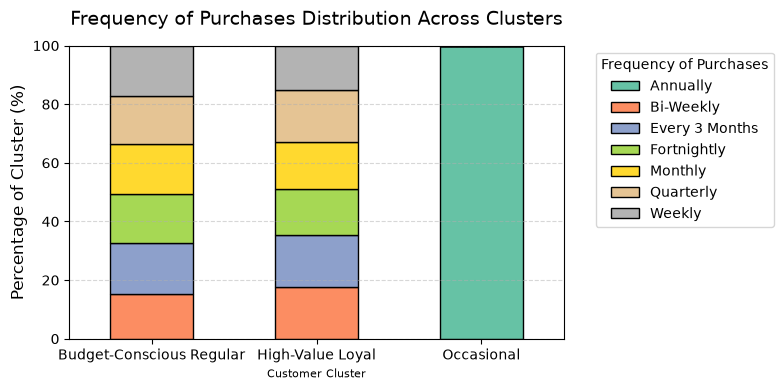

In [74]:
#  1. Create a cross-tabulation showing the percentage breakdown of 'frequency_of_purchases' per cluster
category_distribution = pd.crosstab(
    cluster_df['cluster'], 
    cluster_df['frequency_of_purchases'], 
    normalize='index' # This forces each cluster's row to sum up to 100%
) * 100

print("--- Percentage Distribution of Frequency of Purchases per Cluster ---")
print(category_distribution.round(1))

# 2. Visualize this distribution using a stacked bar chart
category_distribution.plot(
    kind='bar', 
    stacked=True, 
    figsize=(8, 4), 
    colormap='Set2', 
    edgecolor='black'
)

# Customize the chart layout for presentation
plt.title('Frequency of Purchases Distribution Across Clusters', fontsize=14, pad=15)
plt.xlabel('Customer Cluster', fontsize=8)
plt.ylabel('Percentage of Cluster (%)', fontsize=12)
plt.xticks(rotation=0) # Keeps cluster labels horizontal and easy to read
plt.legend(title='Frequency of Purchases', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The model successfully separated the absolute least frequent buyers into their own distinct segment. They only buy once a year. Purchase frequency does not differentiate these two segments. Both groups are active, highly regular shoppers who buy at various intervals throughout the year. Because the Budget-Conscious and High-Value segments look identical here, their true difference lies entirely in how much money they spend, not how often they visit.

--- Percentage Distribution of Age Group per Cluster ---
age_group                 Young Adult  Adult  Middle-Aged  Senior
cluster                                                          
Budget-Conscious Regular         26.2   24.4         25.6    23.8
High-Value Loyal                 27.7   23.1         25.9    23.4
Occasional                       23.1   26.6         22.6    27.8


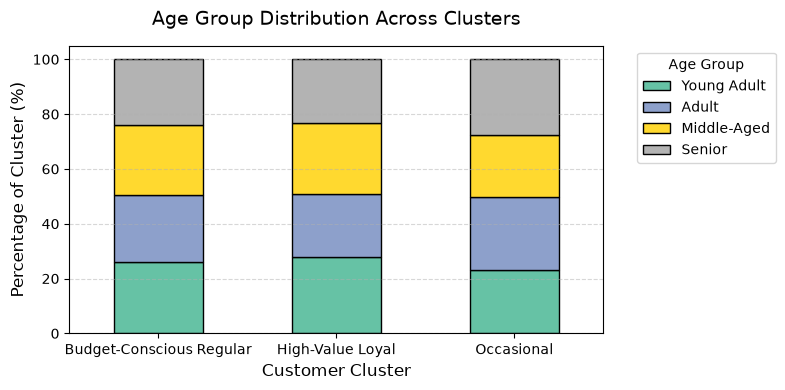

In [75]:
#  1. Create a cross-tabulation showing the percentage breakdown of 'age group' per cluster
category_distribution = pd.crosstab(
    cluster_df['cluster'], 
    cluster_df['age_group'], 
    normalize='index' # This forces each cluster's row to sum up to 100%
) * 100

print("--- Percentage Distribution of Age Group per Cluster ---")
print(category_distribution.round(1))

# 2. Visualize this distribution using a stacked bar chart
category_distribution.plot(
    kind='bar', 
    stacked=True, 
    figsize=(8, 4), 
    colormap='Set2', 
    edgecolor='black'
)

# Customize the chart layout for presentation
plt.title('Age Group Distribution Across Clusters', fontsize=14, pad=15)
plt.xlabel('Customer Cluster', fontsize=12)
plt.ylabel('Percentage of Cluster (%)', fontsize=12)
plt.xticks(rotation=0) # Keeps cluster labels horizontal and easy to read
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Age is more or less evenly distributed across the entire customer base. The segments are purely behavioral, meaning that they are driven by how the customers buy and how much they spend, rather than demographic.

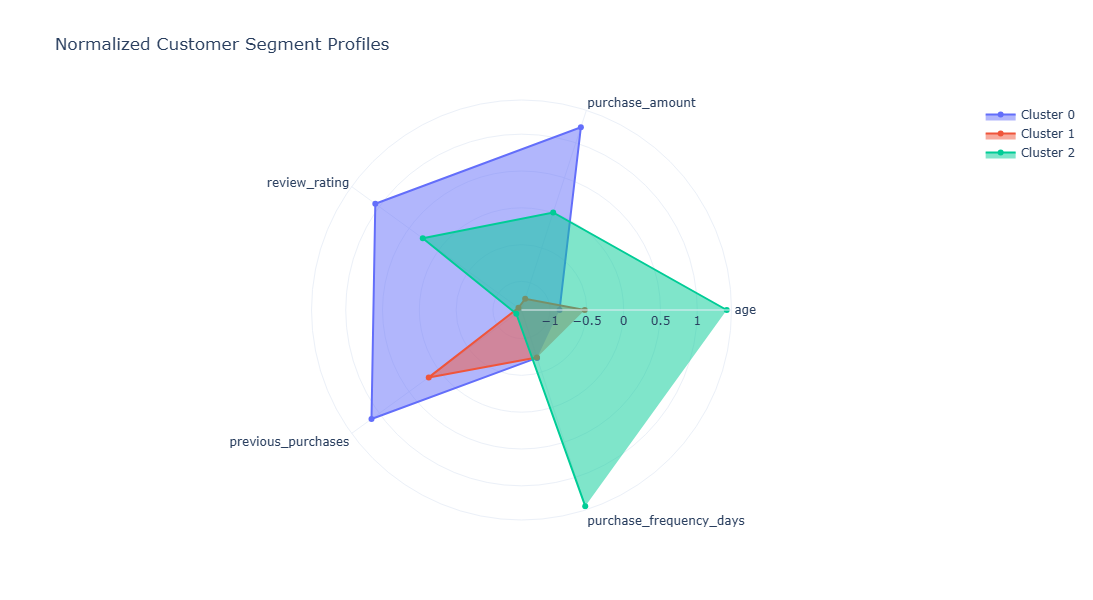

In [76]:
from sklearn.preprocessing import MinMaxScaler

features = ['age', 
            'purchase_amount',
            'review_rating',
            'previous_purchases',
            'purchase_frequency_days',
]

profile_scaled = cluster_summary.copy()
profile_scaled[features] = scaler.fit_transform(cluster_summary[features])

fig = go.Figure()

for cluster in profile_scaled.index:
    fig.add_trace(go.Scatterpolar(
        r=profile_scaled.loc[cluster, features].values,
        theta=features,
        fill='toself',
        name=f'Cluster {cluster}'
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
        )
    ),
    title='Normalized Customer Segment Profiles',
    template='plotly_white',
    width=800,
    height=600,
)

fig.show()

The radar chart highlights clear behavioral differences among the three customer segments. Cluster 0 exhibits the strongest customer value, characterized by high purchase amounts, numerous previous purchases, and positive review ratings. Cluster 1 consists of regular but lower-spending customers. Cluster 2 is distinguished by its significantly longer purchase intervals and lower purchase activity, suggesting these customers may require targeted retention strategies to improve engagement.

<a id="br"></a>
# 14. Business Recommendations


**High-Value Loyal Buyers**
* Offer VIP treatment through exclusive offers
* Focus on customer retention through personalized communication
* Provide loyalty rewards

**Budget-Conscious Regular Customers**
* Encourage higher basket values through cross-selling and bundle offers
* Send personalized promotions
* Recommend complementary products


**Occasional Customers**
* Offer seasonal discounts
* Send reminders and personalized recommendations
* Encourage repeat purchases through exclusive offers
* Introduce first-time buyer incentives


#### Customer Segment Summary

| Cluster | Profile | Priority |
|---------|---------|----------|
| **0** | High-Value Loyal Customers | Retain and reward|
| **1** | Budget-Conscious Regular Customers | Increase spending through upselling and cross-selling |
| **2** | Occassional Customers | Reactivate with targeted marketing campaigns |

<a id="con"></a>
# 15. Conclusion

This project compared K-Means, Agglomerative Hierarchical Clustering and Gaussian Mixture Models for customer segmentation.

After evaluating multiple PCA variance thresholds and hyperparameter combinations using Silhouette, Calinski-Harabasz and Davies-Bouldin scores, K-Means Clustering model produced meaningful customer segments.

These segments can be used to improve:
- marketing campaigns
- customer retention
- product recommendations
- promotional targeting

<a id="ecomet"></a>
# 16. End Commet Experiment


In [77]:
#experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : 15th one
COMET INFO:     url                   : https://www.comet.com/msibivee-gmail-com/customer-segmentation/ba85045629b54852920446b01e051782
COMET INFO:   Others:
COMET INFO:     Name : 15th one
COMET INFO:   Parameters:
COMET INFO:     algorithm          : lloyd
COMET INFO:     compute_distances  : False
COMET INFO:     compute_full_tree  : auto
COMET INFO:     connectivity       : None
COMET INFO:     copy               : True
COMET INFO:     copy_x             : True
COMET INFO:     covariance_type    : full
COMET INFO:     distance_threshold : None
COMET INFO:     init               : random
COMET INFO:     init_params        : kmeans
COMET I

In [78]:
#experiment.display()